In [1]:
import matplotlib.pyplot as plt

try:
    import cirq
except ImportError:
    print("installing cirq...")
    !pip install cirq --quiet
    import cirq
    print("installed cirq.")

print("Libraries Successfully Imported")

Libraries Successfully Imported


In [2]:
#create the 3 data qubits and 2 ancilla qubits
q0, q1, q2 = cirq.LineQubit.range(3)
a0, a1 = cirq.LineQubit.range(3, 5)

circuit = cirq.Circuit()

In [4]:
#put q0 into the |+> state
#whole system is now (|000> + |100>) / sqrt(2)
circuit.append(cirq.H(q0))


#encode the logical qubit across 3 physical qubits
circuit.append(cirq.CNOT(q0, q1))
circuit.append(cirq.CNOT(q0, q2))

#GHZ state is now (|000> + |111>) / sqrt(2)


#switch into the phase flip basis
#HZH = X so i can detect Z errors like X errors
circuit.append(cirq.H(q0))
circuit.append(cirq.H(q1))
circuit.append(cirq.H(q2))

#encoded state is now (|+++> + |--->) / sqrt(2)


print("Initial phase-flip encoding:")
print(circuit)


Initial phase-flip encoding:
              ┌──┐               ┌──┐
0: ───H───@────@─────H───H───@────@─────H───
          │    │             │    │
1: ───────X────┼H────────────X────┼H────────
               │                  │
2: ────────────X─────H────────────X─────H───
              └──┘               └──┘


In [5]:
#add a phase flip error on q1
circuit.append(cirq.Z(q1))


print("After injecting a phase-flip error on q1:\n")
print(circuit)


#go back to the computational basis
#now the Z error behaves like an X error
circuit.append(cirq.H(q0))
circuit.append(cirq.H(q1))
circuit.append(cirq.H(q2))


#compare q0 and q1 using a0
circuit.append(cirq.CNOT(q0, a0))
circuit.append(cirq.CNOT(q1, a0))


#compare q1 and q2 using a1
circuit.append(cirq.CNOT(q1, a1))
circuit.append(cirq.CNOT(q2, a1))


#measure the ancillas to get the syndrome
circuit.append(cirq.measure(a0, key="syndrome1"))
circuit.append(cirq.measure(a1, key="syndrome2"))


print("Circuit used for syndrome extraction:\n")
print(circuit)

After injecting a phase-flip error on q1:

              ┌──┐               ┌──┐
0: ───H───@────@─────H───H───@────@─────H───
          │    │             │    │
1: ───────X────┼H────────────X────┼H────Z───
               │                  │
2: ────────────X─────H────────────X─────H───
              └──┘               └──┘

Circuit used for syndrome extraction:

              ┌──┐               ┌──┐                   ┌───────────────┐
0: ───H───@────@─────H───H───@────@─────H───H───@────────────────────────────────────────────────
          │    │             │    │             │
1: ───────X────┼H────────────X────┼H────Z───H───┼───@────@───────────────────────────────────────
               │                  │             │   │    │
2: ────────────X─────H────────────X─────H───H───┼───┼────┼──────────────────@────────────────────
                                                │   │    │                  │
3: ─────────────────────────────────────────────X───X────┼M('syndrome1')────┼──

In [6]:
#run the syndrome circuit
sim = cirq.Simulator()

syndrome_result = sim.run(
    circuit,
    repetitions=1
)


#get the first syndrome measurement
syndrome1 = int(
    syndrome_result.measurements["syndrome1"][0][0]
)


#get the second syndrome measurement
syndrome2 = int(
    syndrome_result.measurements["syndrome2"][0][0]
)


#put both measurements together
syndrome = (syndrome1, syndrome2)

print("\nMeasured syndrome:", syndrome)


#q1 should give the syndrome (1, 1)
expected_syndrome = (1, 1)

print("Expected syndrome:", expected_syndrome)


if syndrome == expected_syndrome:
    print("Correct syndrome detected")
else:
    print("Unexpected syndrome")


#figure out which qubit has the error
if syndrome == (1, 0):
    error_location = 0

elif syndrome == (1, 1):
    error_location = 1

elif syndrome == (0, 1):
    error_location = 2

else:
    error_location = None


#print which qubit the syndrome points to
if error_location == 0:
    print("Detected error: q0")

elif error_location == 1:
    print("Detected error: q1")

elif error_location == 2:
    print("Detected error: q2")

else:
    print("No error detected")


Measured syndrome: (1, 0)
Expected syndrome: (1, 1)
Unexpected syndrome
Detected error: q0


In [8]:
#rebuild the circuit so i can apply the correction
corrected_circuit = cirq.Circuit()


#make the original |+> state again
corrected_circuit.append(cirq.H(q0))


#encode it across the 3 qubits again
corrected_circuit.append(cirq.CNOT(q0, q1))
corrected_circuit.append(cirq.CNOT(q0, q2))


#switch into the phase flip basis again
corrected_circuit.append(cirq.H(q0))
corrected_circuit.append(cirq.H(q1))
corrected_circuit.append(cirq.H(q2))


#add the same error again
corrected_circuit.append(cirq.Z(q1))


#fix whichever qubit the syndrome points to
if error_location == 0:
    corrected_circuit.append(cirq.Z(q0))

elif error_location == 1:
    corrected_circuit.append(cirq.Z(q1))

elif error_location == 2:
    corrected_circuit.append(cirq.Z(q2))


#the two Z gates cancel each other out


#go back from the phase flip basis
corrected_circuit.append(cirq.H(q0))
corrected_circuit.append(cirq.H(q1))
corrected_circuit.append(cirq.H(q2))

In [9]:
#undo the encoding
corrected_circuit.append(cirq.CNOT(q0, q1))
corrected_circuit.append(cirq.CNOT(q0, q2))


#the recovered state should be |+>
#use H so it becomes |0> before measuring
corrected_circuit.append(cirq.H(q0))


#measure the recovered qubit
corrected_circuit.append(
    cirq.measure(q0, key="recovered")
)


print("\nFull correction and decoding circuit:\n")
print(corrected_circuit)


Full correction and decoding circuit:

              ┌──┐
0: ───H───@────@─────H───Z───H───@───@───H───M('recovered')───
          │    │                 │   │
1: ───────X────┼H────Z───H───────X───┼────────────────────────
               │                     │
2: ────────────X─────H───H───────────X────────────────────────
              └──┘



Recovered logical state results:
Counter({0: 1000})


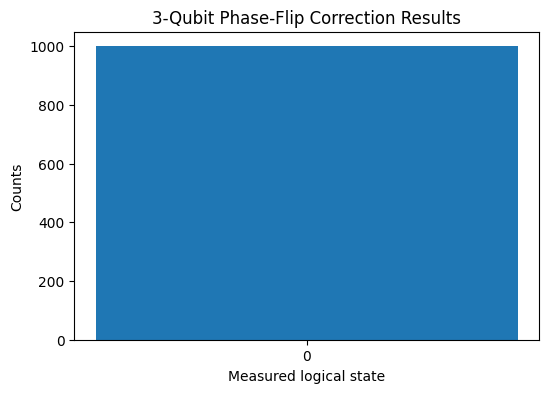

In [10]:

#run the corrected circuit 1000 times
final_result = sim.run(
    corrected_circuit,
    repetitions=1000
)


#get the final measurement counts
histogram = final_result.histogram(
    key="recovered"
)


print("\nRecovered logical state results:")
print(histogram)


#make the labels and counts for the graph
labels = []
counts = []

for state in histogram:
    labels.append(str(state))
    counts.append(histogram[state])


#make the graph
plt.figure(figsize=(6, 4))
plt.bar(labels, counts)
plt.xlabel("Measured logical state")
plt.ylabel("Counts")
plt.title("3-Qubit Phase-Flip Correction Results")
plt.show()